In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from imblearn.under_sampling import RandomUnderSampler
from sklearn.feature_selection import VarianceThreshold, SelectKBest, f_classif
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report, roc_curve, auc
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.layers import Dropout
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

In [ ]:
df=pd.read_csv("/content/Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv")

In [ ]:
df.head()

,Flow ID,Source IP,Source Port,Destination IP,Destination Port,Protocol,Timestamp,Flow Duration,Total Fwd Packets,Total Backward Packets,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,192.168.10.5-104.16.207.165-54865-443-6,104.16.207.165,443,192.168.10.5,54865,6,7/7/2017 3:30,3,2,0,...,20.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN
1,192.168.10.5-104.16.28.216-55054-80-6,104.16.28.216,80,192.168.10.5,55054,6,7/7/2017 3:30,109,1,1,...,20.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN
2,192.168.10.5-104.16.28.216-55055-80-6,104.16.28.216,80,192.168.10.5,55055,6,7/7/2017 3:30,52,1,1,...,20.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN
3,192.168.10.16-104.17.241.25-46236-443-6,104.17.241.25,443,192.168.10.16,46236,6,7/7/2017 3:30,34,1,1,...,20.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN
4,192.168.10.5-104.19.196.102-54863-443-6,104.19.196.102,443,192.168.10.5,54863,6,7/7/2017 3:30,3,2,0,...,20.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10429 entries, 0 to 10428
Data columns (total 85 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Flow ID                       10429 non-null  object 
 1    Source IP                    10429 non-null  object 
 2    Source Port                  10429 non-null  int64  
 3    Destination IP               10429 non-null  object 
 4    Destination Port             10429 non-null  int64  
 5    Protocol                     10429 non-null  int64  
 6    Timestamp                    10429 non-null  object 
 7    Flow Duration                10429 non-null  int64  
 8    Total Fwd Packets            10429 non-null  int64  
 9    Total Backward Packets       10429 non-null  int64  
 10  Total Length of Fwd Packets   10429 non-null  int64  
 11   Total Length of Bwd Packets  10429 non-null  int64  
 12   Fwd Packet Length Max        10428 non-null  float64
 13   

In [ ]:
df.columns

Index(['Flow ID', ' Source IP', ' Source Port', ' Destination IP',
       ' Destination Port', ' Protocol', ' Timestamp', ' Flow Duration',
       ' Total Fwd Packets', ' Total Backward Packets',
       'Total Length of Fwd Packets', ' Total Length of Bwd Packets',
       ' Fwd Packet Length Max', ' Fwd Packet Length Min',
       ' Fwd Packet Length Mean', ' Fwd Packet Length Std',
       'Bwd Packet Length Max', ' Bwd Packet Length Min',
       ' Bwd Packet Length Mean', ' Bwd Packet Length Std', 'Flow Bytes/s',
       ' Flow Packets/s', ' Flow IAT Mean', ' Flow IAT Std', ' Flow IAT Max',
       ' Flow IAT Min', 'Fwd IAT Total', ' Fwd IAT Mean', ' Fwd IAT Std',
       ' Fwd IAT Max', ' Fwd IAT Min', 'Bwd IAT Total', ' Bwd IAT Mean',
       ' Bwd IAT Std', ' Bwd IAT Max', ' Bwd IAT Min', 'Fwd PSH Flags',
       ' Bwd PSH Flags', ' Fwd URG Flags', ' Bwd URG Flags',
       ' Fwd Header Length', ' Bwd Header Length', 'Fwd Packets/s',
       ' Bwd Packets/s', ' Min Packet Length', ' Max Pa

In [ ]:
# Check for missing values
missing_values = df.isnull().sum()
print("Missing Values:\n", missing_values)

Missing Values:
 Flow ID              0
 Source IP           0
 Source Port         0
 Destination IP      0
 Destination Port    0
                    ..
Idle Mean            1
 Idle Std            1
 Idle Max            1
 Idle Min            1
 Label               1
Length: 85, dtype: int64


In [ ]:
# Iterate over columns with missing values
columns_with_missing_values = []
for column, count in missing_values.items():
    if count > 0:
        columns_with_missing_values.append(column)

# Print columns with missing values
print("Columns with Missing Values:")
for column in columns_with_missing_values:
    print(f"{column}: {missing_values[column]} missing values")

Columns with Missing Values:
 Fwd Packet Length Max: 1 missing values
 Fwd Packet Length Min: 1 missing values
 Fwd Packet Length Mean: 1 missing values
 Fwd Packet Length Std: 1 missing values
Bwd Packet Length Max: 1 missing values
 Bwd Packet Length Min: 1 missing values
 Bwd Packet Length Mean: 1 missing values
 Bwd Packet Length Std: 1 missing values
Flow Bytes/s: 2 missing values
 Flow Packets/s: 1 missing values
 Flow IAT Mean: 1 missing values
 Flow IAT Std: 1 missing values
 Flow IAT Max: 1 missing values
 Flow IAT Min: 1 missing values
Fwd IAT Total: 1 missing values
 Fwd IAT Mean: 1 missing values
 Fwd IAT Std: 1 missing values
 Fwd IAT Max: 1 missing values
 Fwd IAT Min: 1 missing values
Bwd IAT Total: 1 missing values
 Bwd IAT Mean: 1 missing values
 Bwd IAT Std: 1 missing values
 Bwd IAT Max: 1 missing values
 Bwd IAT Min: 1 missing values
Fwd PSH Flags: 1 missing values
 Bwd PSH Flags: 1 missing values
 Fwd URG Flags: 1 missing values
 Bwd URG Flags: 1 missing values
 Fw

In [ ]:
# as we have less number of Missing Values, We will be dropping the rows with missing values
df = df.dropna()

# EDA

In [ ]:
# Summary statistics for numeric columns
print("\nSummary Statistics:")
print(df.describe())


Summary Statistics:
        Source Port   Destination Port      Protocol   Flow Duration  \
count  10427.000000       10427.000000  10427.000000    1.042700e+04   
mean   41069.741728        7410.886640     11.007672    1.210052e+07   
std    22962.083517       17844.177741      5.481754    3.117381e+07   
min        0.000000           0.000000      0.000000    0.000000e+00   
25%    22649.000000          53.000000      6.000000    2.070000e+02   
50%    53379.000000          80.000000      6.000000    4.711900e+04   
75%    58159.500000         443.000000     17.000000    9.232015e+05   
max    65532.000000       61463.000000     17.000000    1.199981e+08   

        Total Fwd Packets   Total Backward Packets  \
count        10427.000000             10427.000000   
mean             7.486238                 7.734056   
std             23.415571                30.561997   
min              1.000000                 0.000000   
25%              2.000000                 1.000000   
50%   

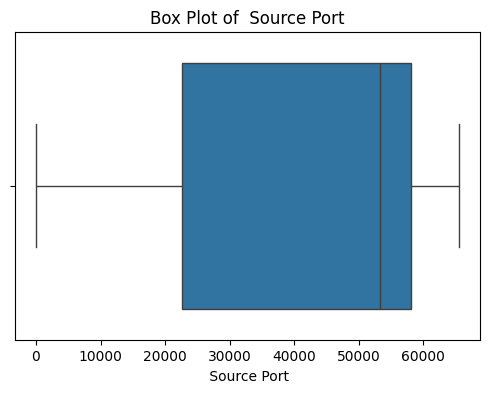

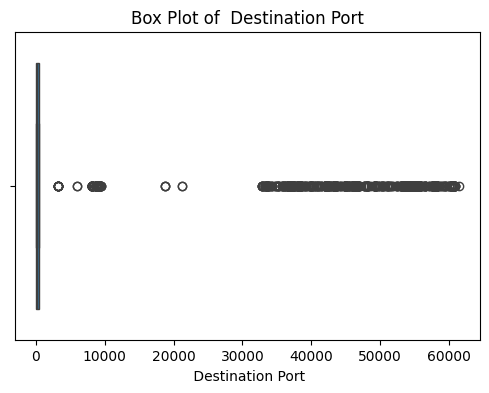

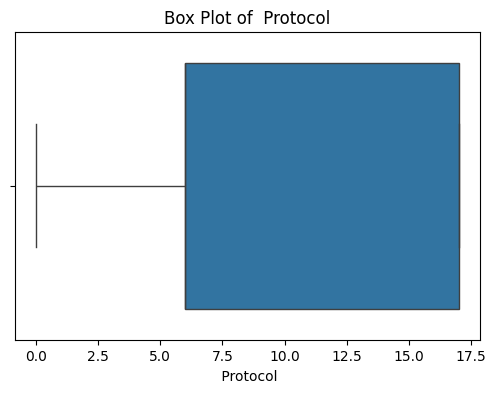

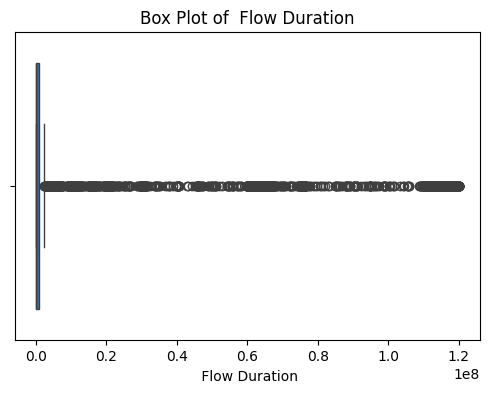

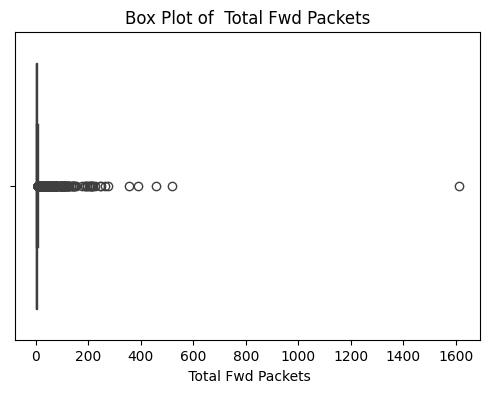

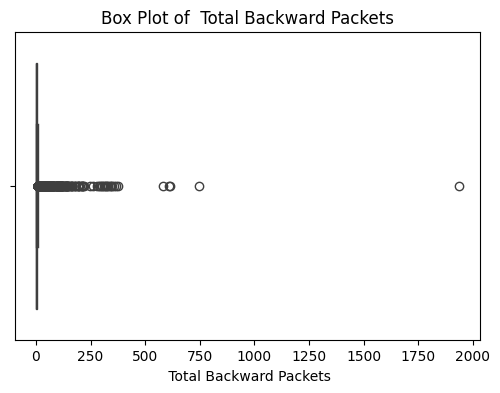

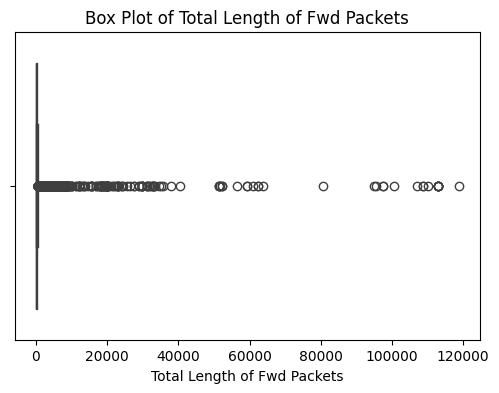

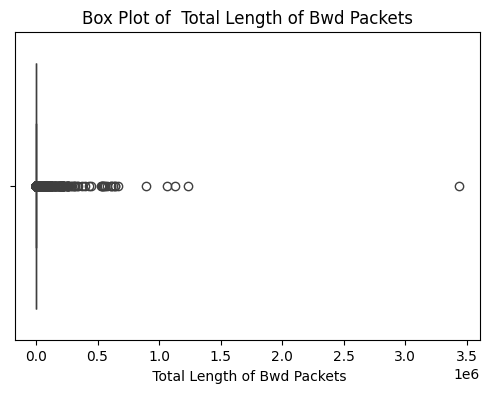

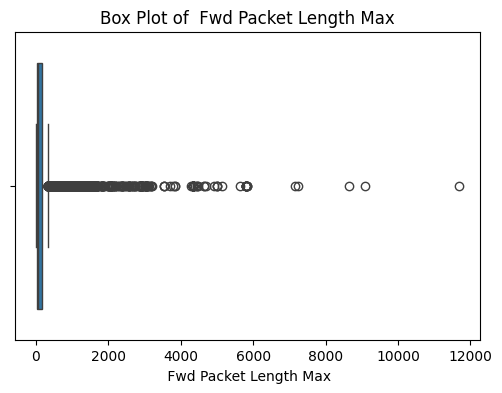

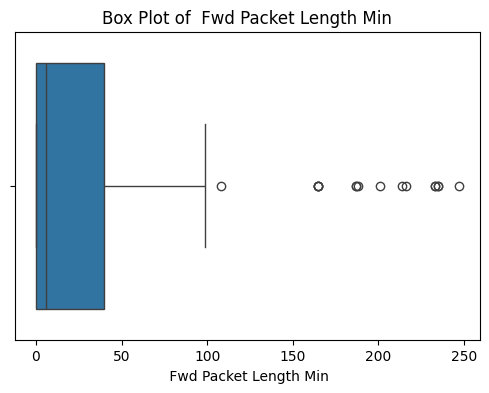

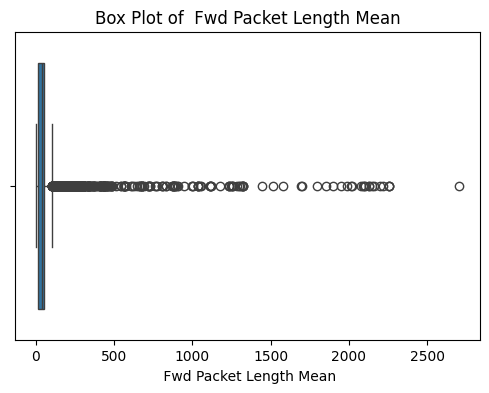

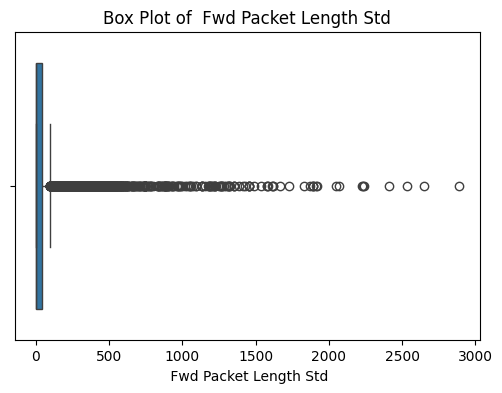

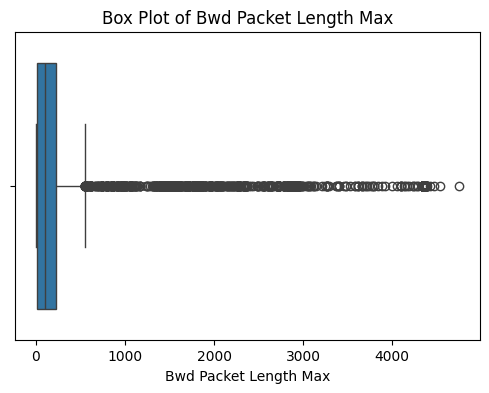

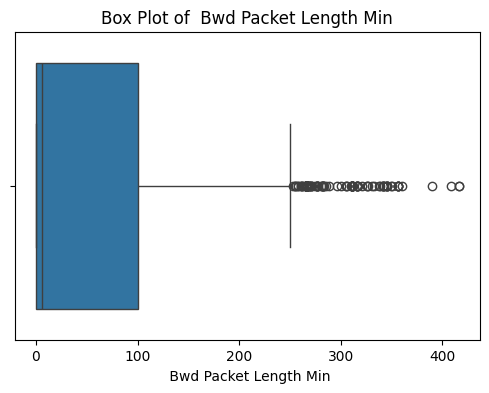

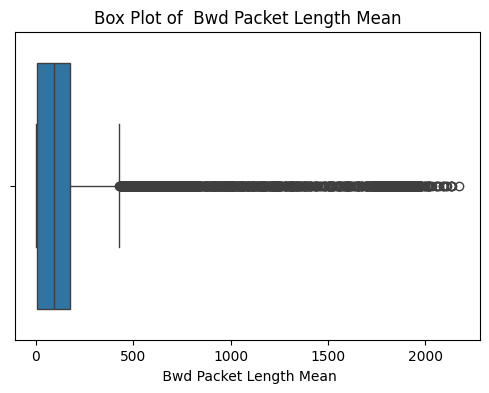

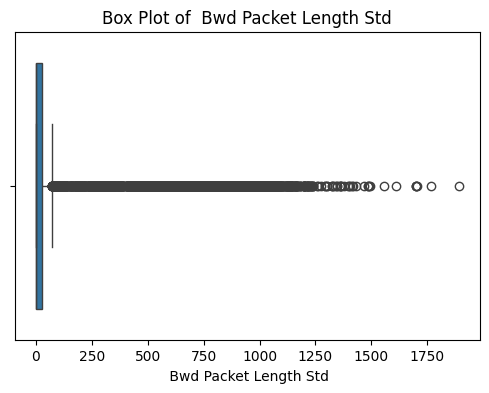

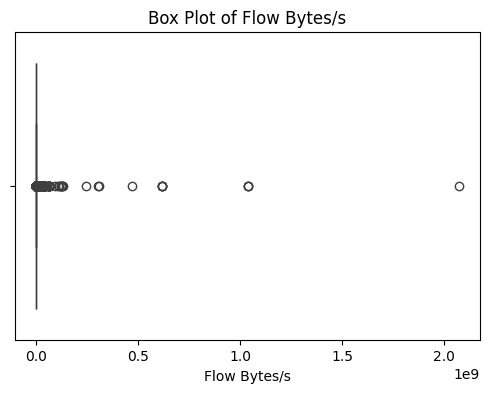

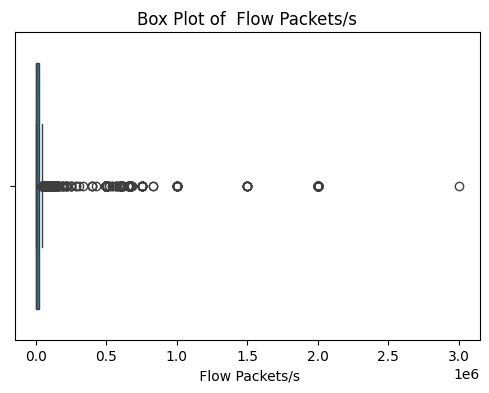

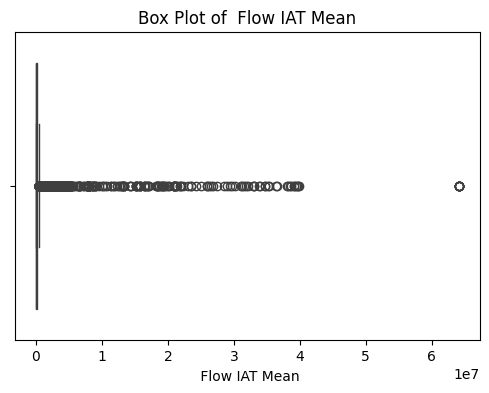

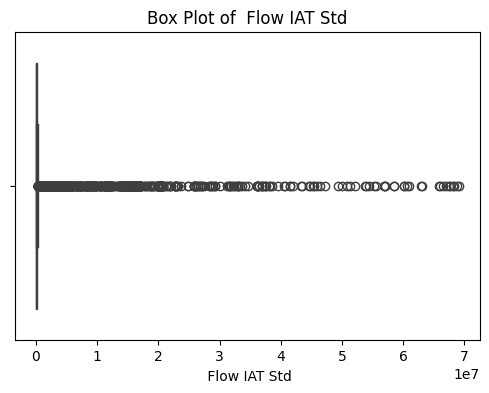

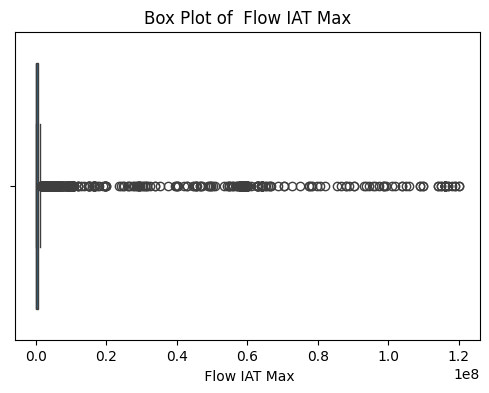

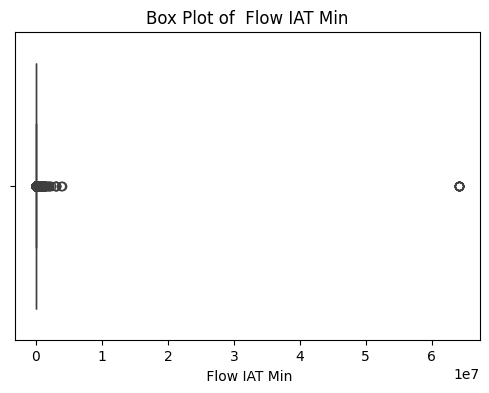

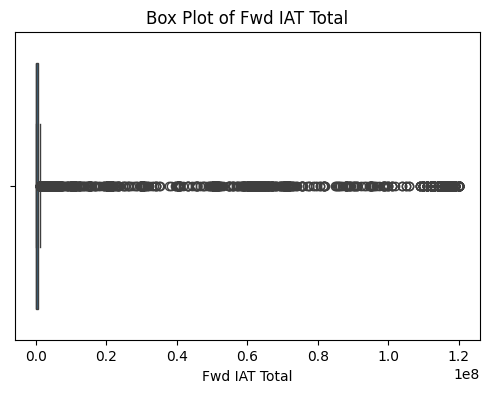

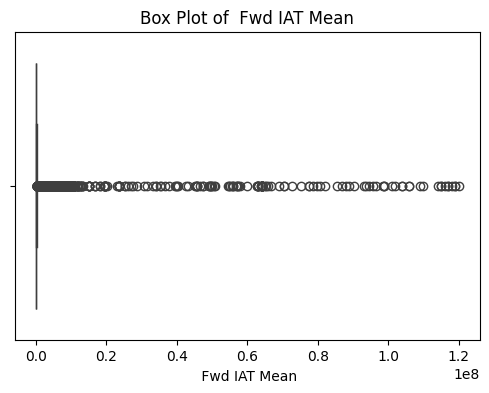

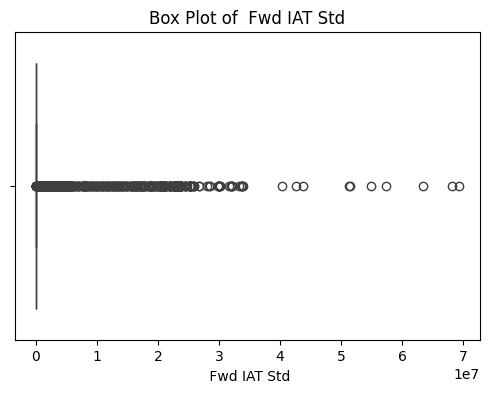

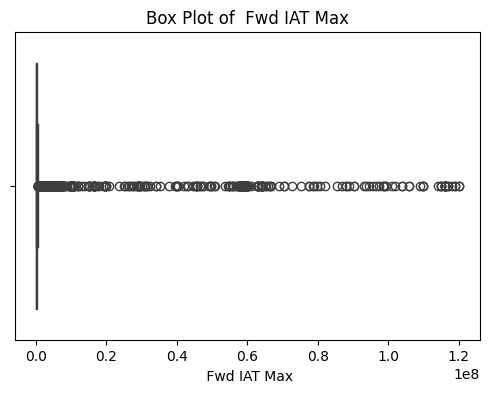

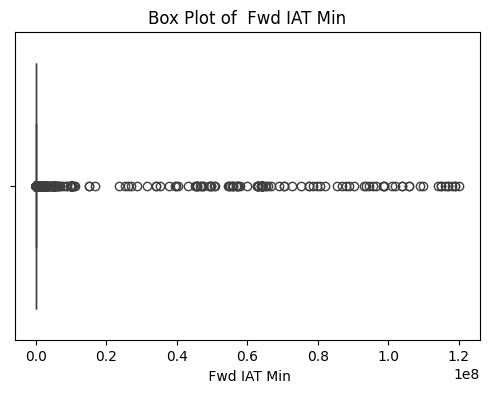

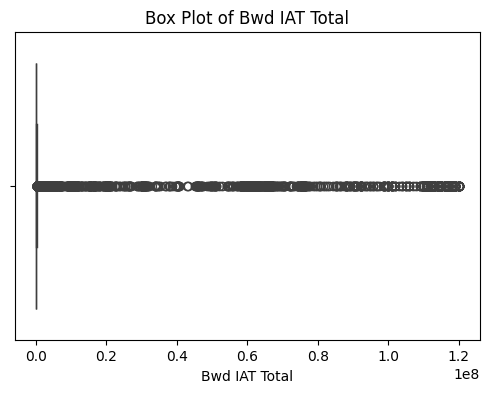

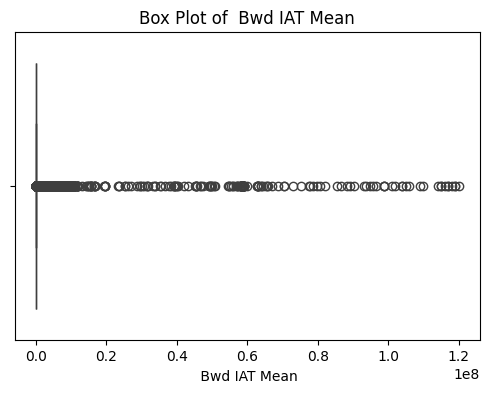

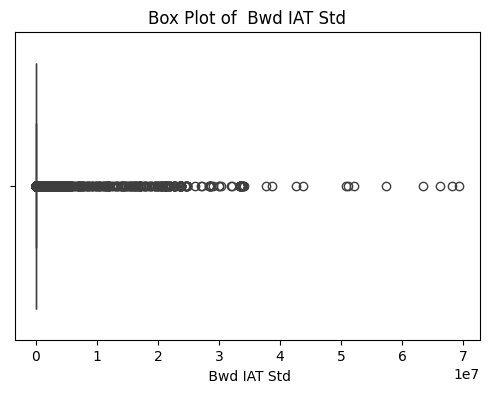

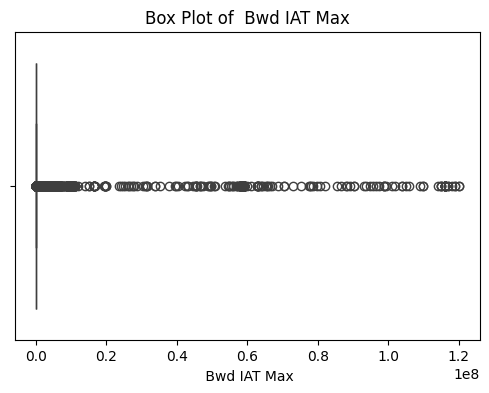

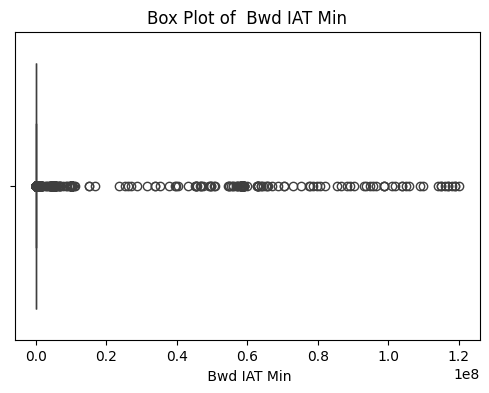

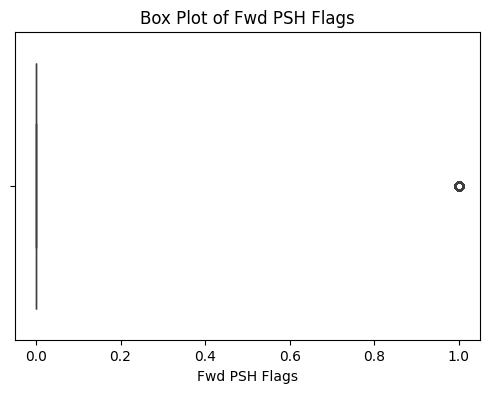

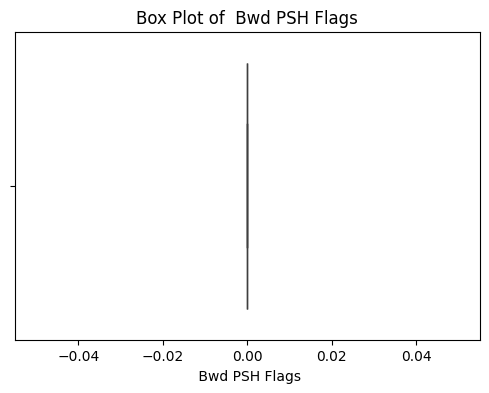

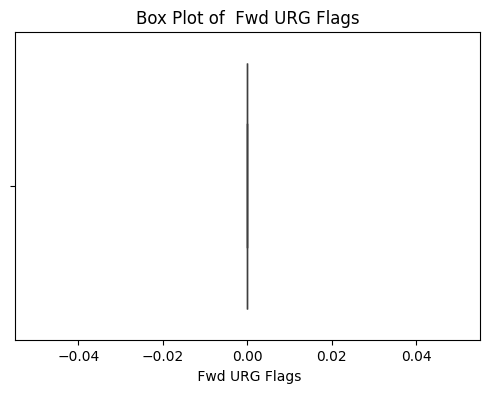

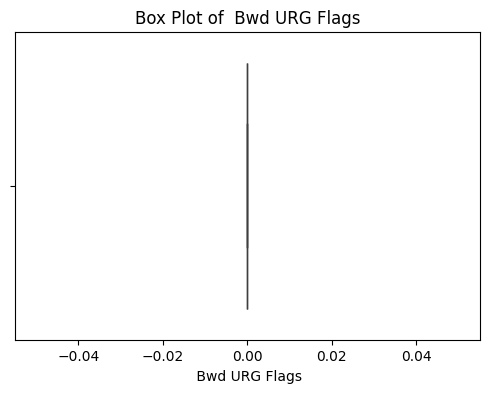

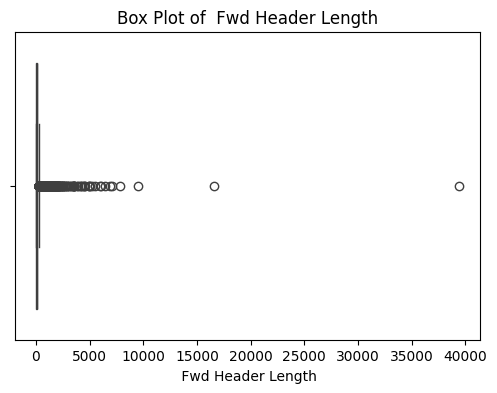

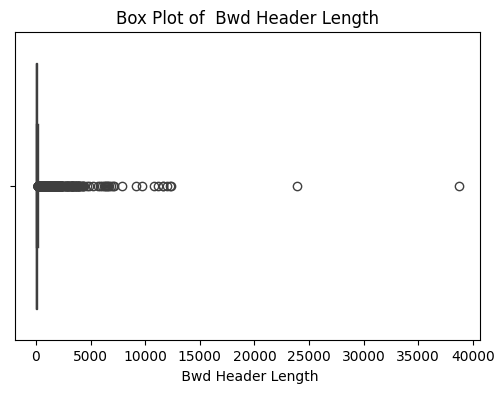

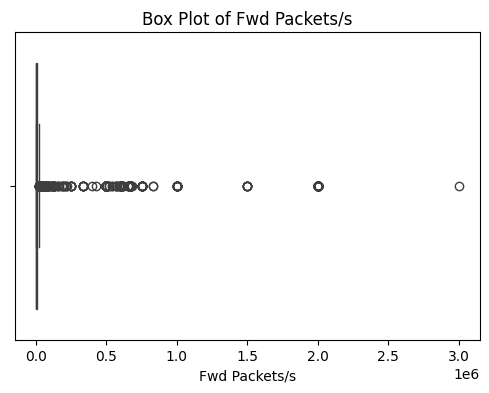

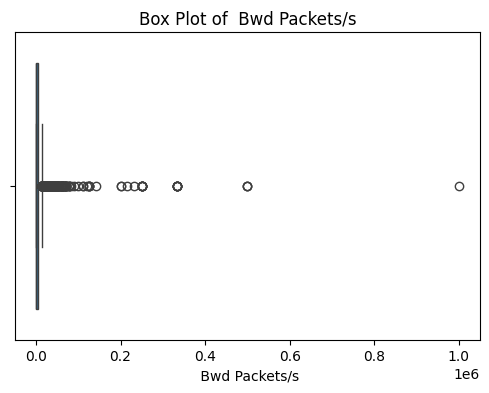

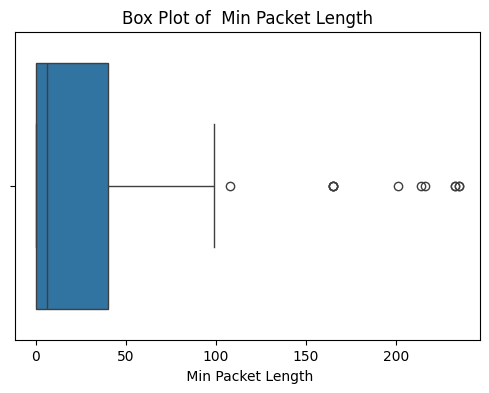

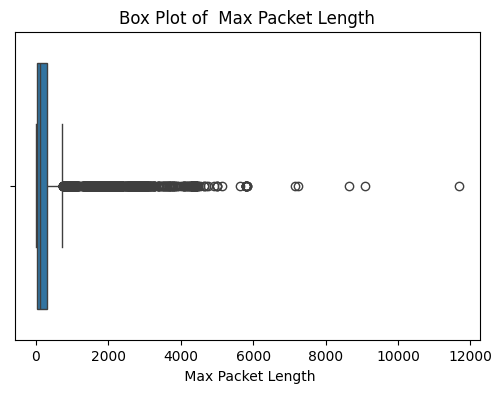

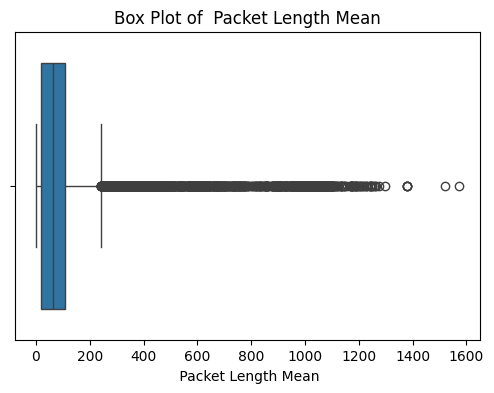

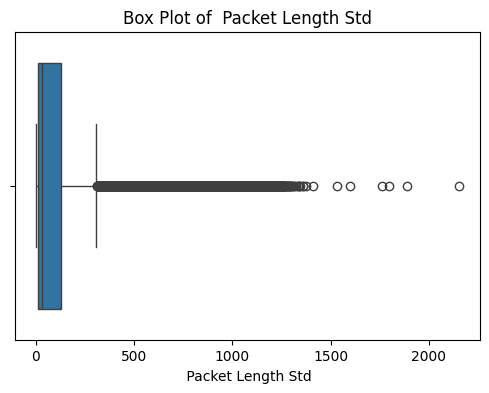

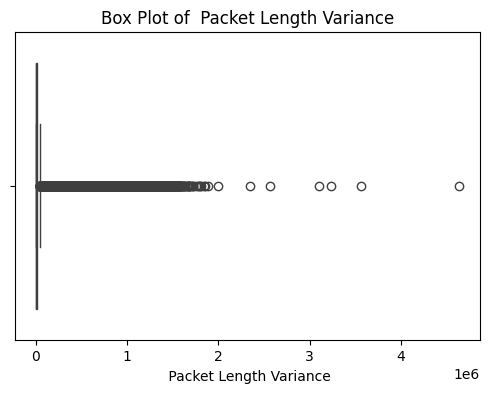

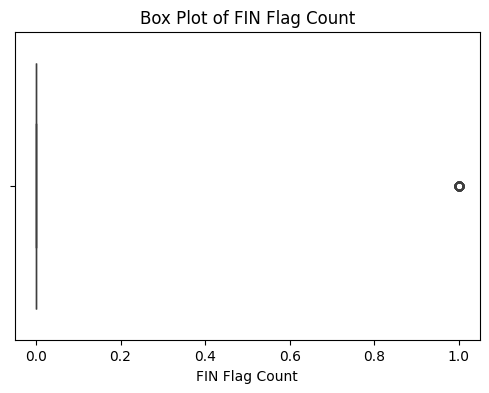

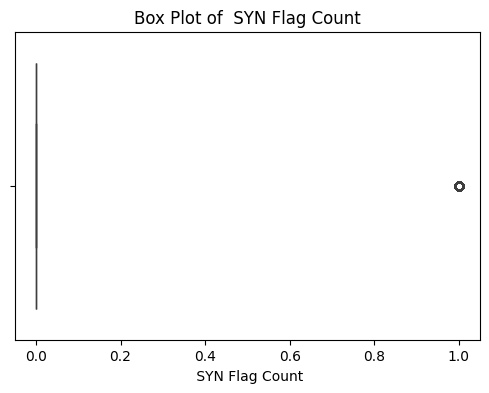

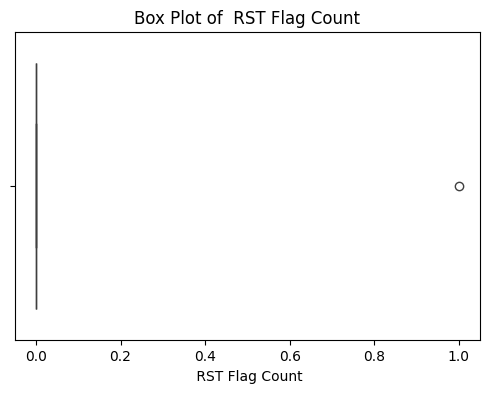

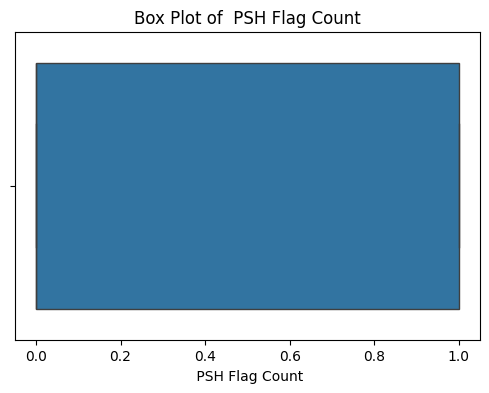

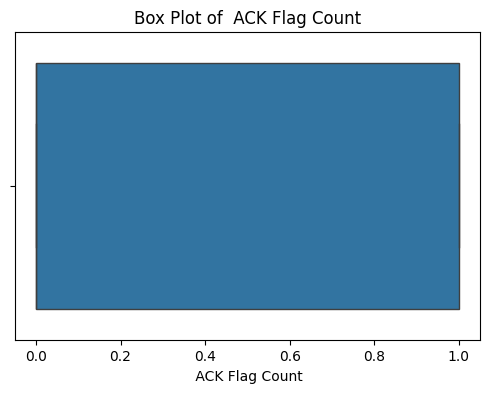

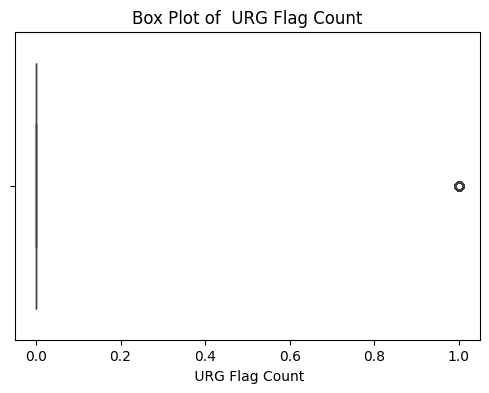

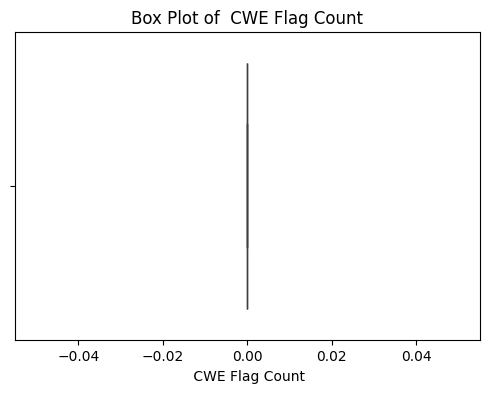

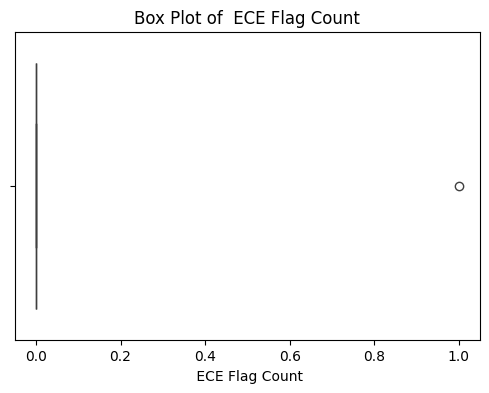

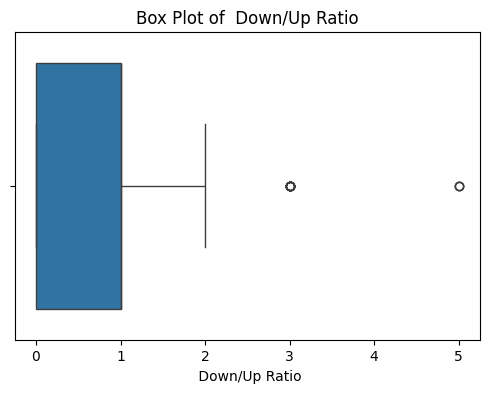

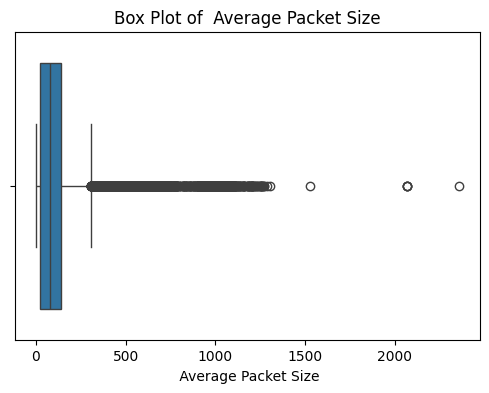

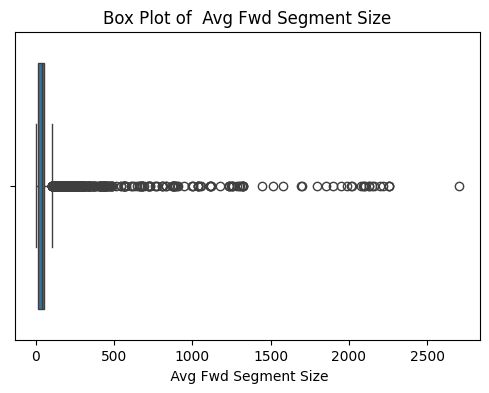

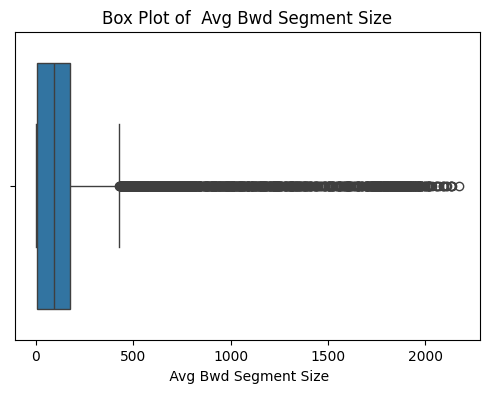

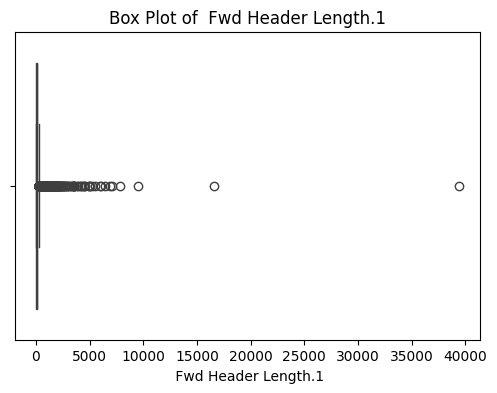

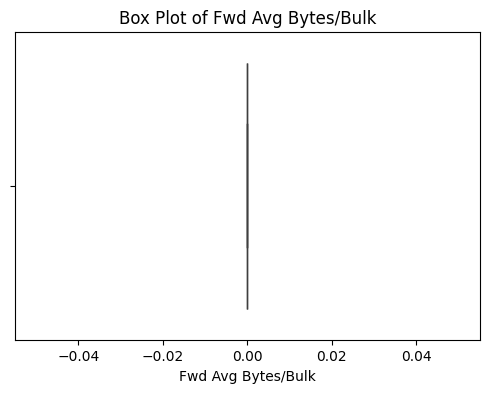

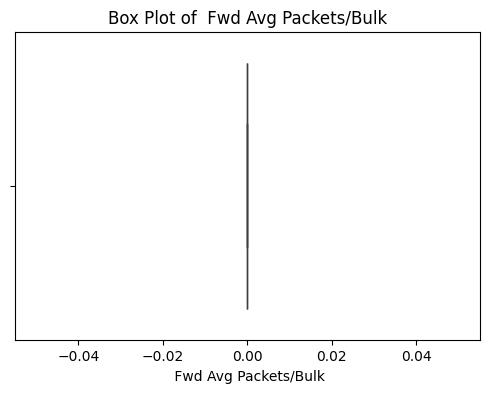

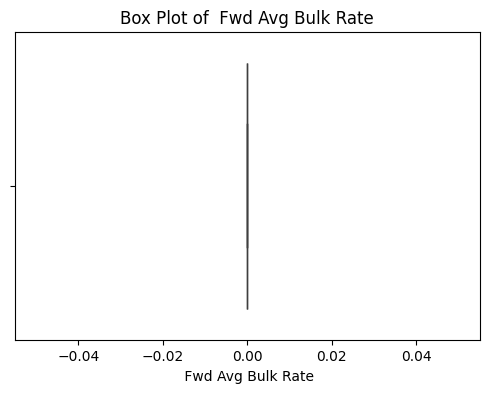

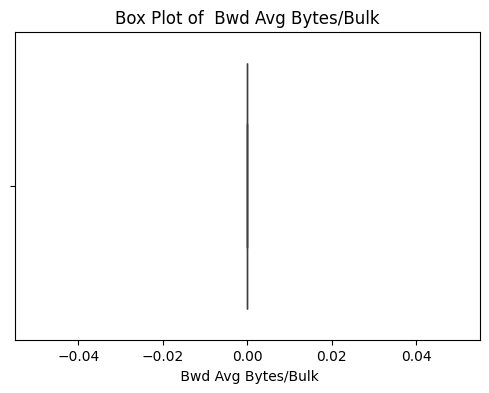

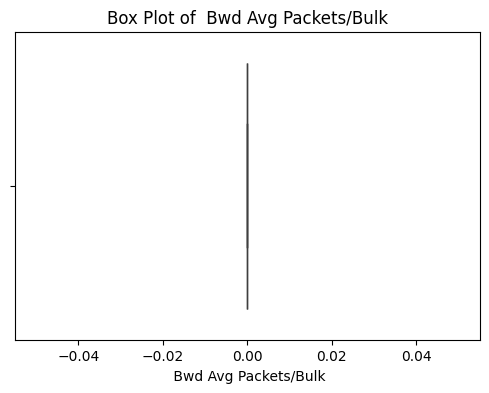

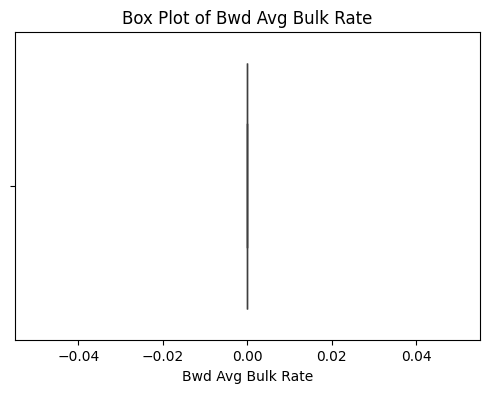

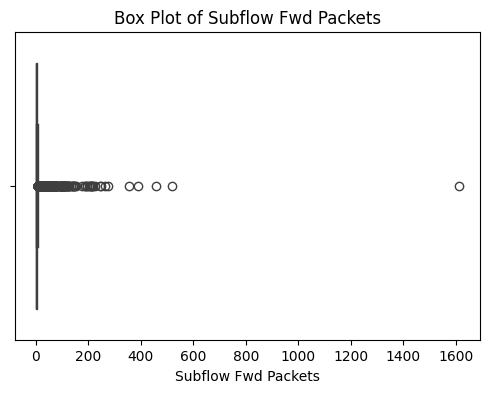

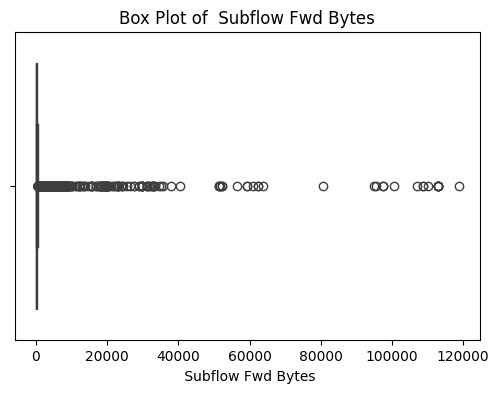

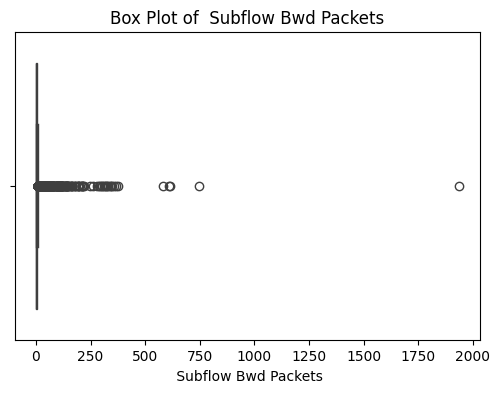

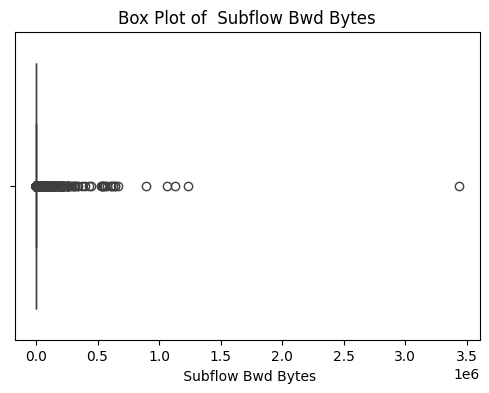

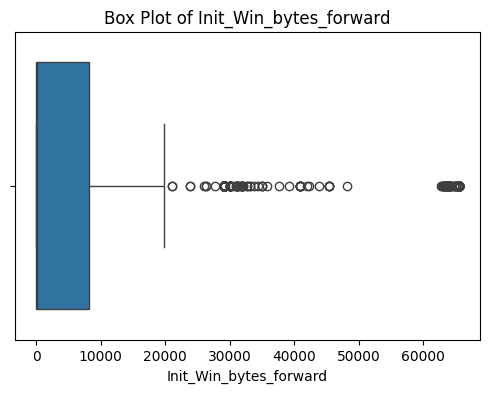

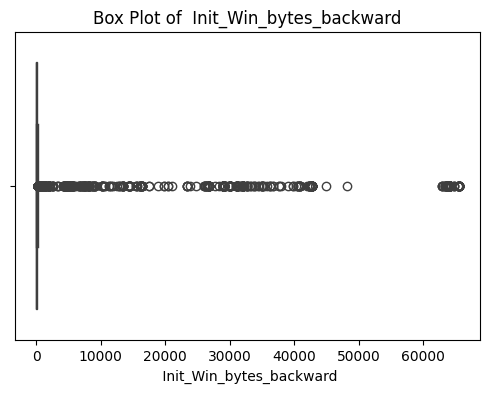

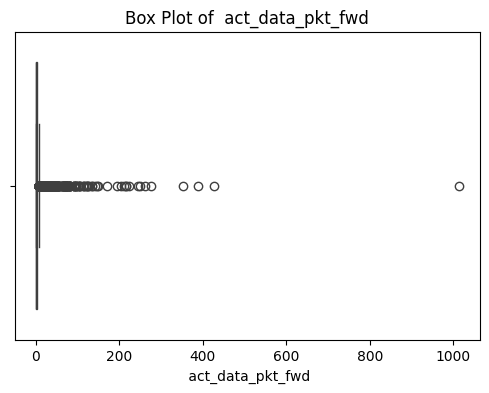

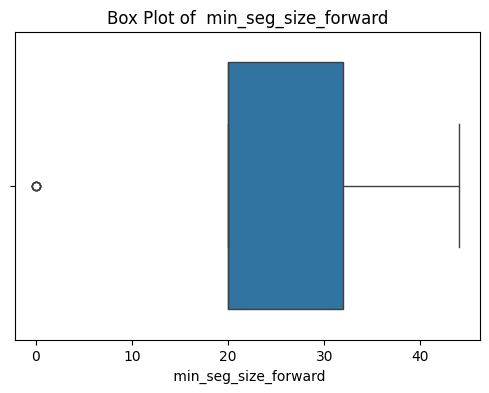

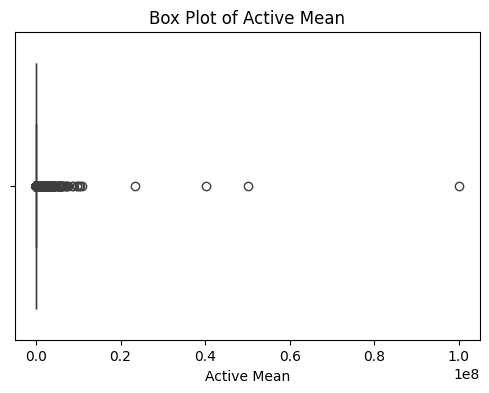

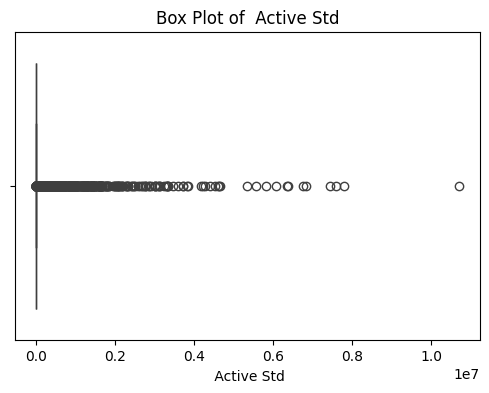

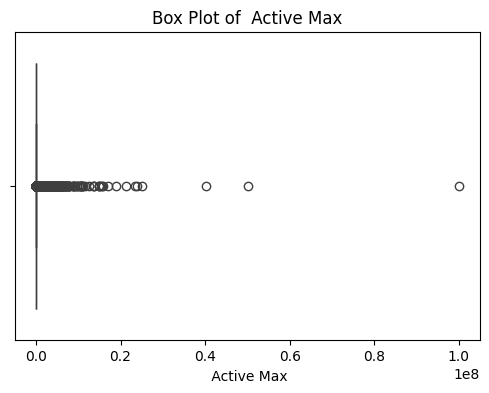

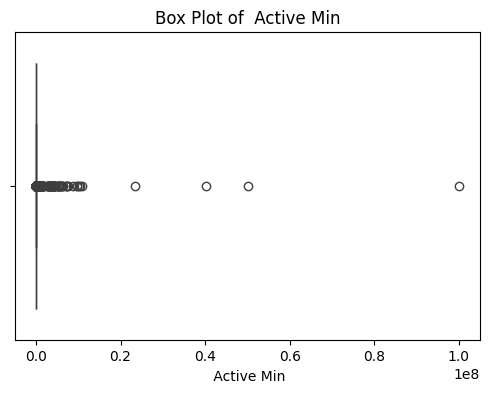

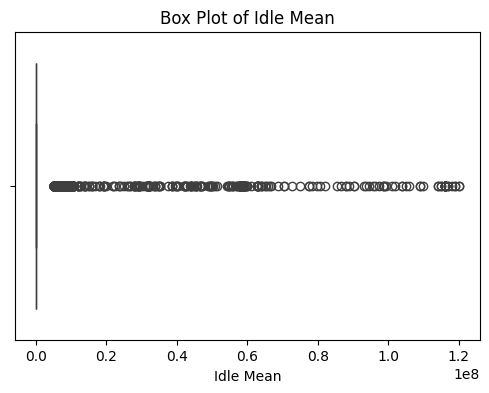

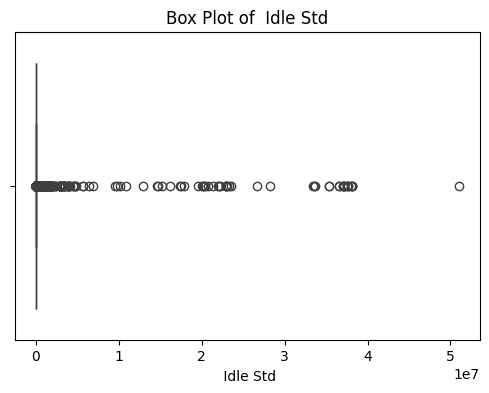

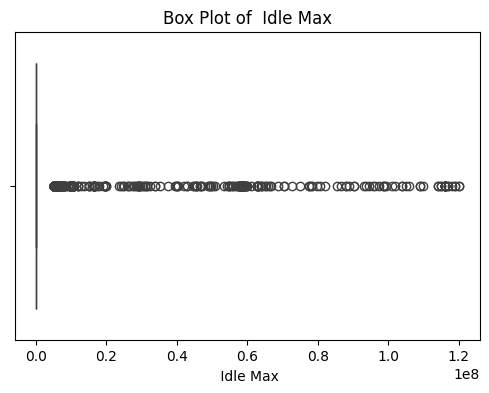

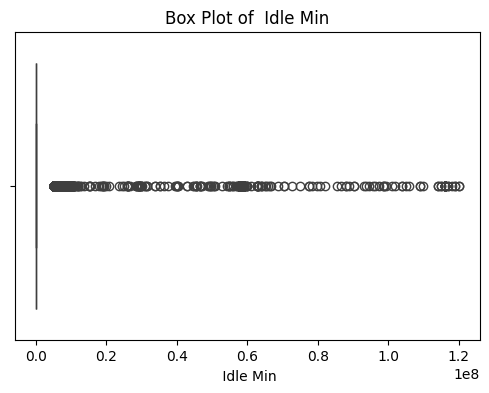

In [ ]:
# Box plots for numeric columns
numeric_cols = df.select_dtypes(include=np.number).columns
for col in numeric_cols:
    plt.figure(figsize=(6, 4))
    sns.boxplot(data=df, x=col)
    plt.title(f'Box Plot of {col}')
    plt.show()

In [ ]:
# Initialize the label encoder
label_encoder = LabelEncoder()

# Encode the 'Source IP' column
df['Source IP'] = label_encoder.fit_transform(df[' Source IP'])

# Encode the 'Destination IP' column
df['Destination IP'] = label_encoder.fit_transform(df[' Destination IP'])

# Encode the 'Label' column (assuming 'DDoS' is 1 and 'Benign' is 0)
df['Label'] = label_encoder.fit_transform(df[' Label'])

In [ ]:
df

,Flow ID,Source IP,Source Port,Destination IP,Destination Port,Protocol,Timestamp,Flow Duration,Total Fwd Packets,Total Backward Packets,...,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label,Source IP,Destination IP,Label
0,192.168.10.5-104.16.207.165-54865-443-6,104.16.207.165,443,192.168.10.5,54865,6,7/7/2017 3:30,3,2,0,...,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN,2,246,0
1,192.168.10.5-104.16.28.216-55054-80-6,104.16.28.216,80,192.168.10.5,55054,6,7/7/2017 3:30,109,1,1,...,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN,7,246,0
2,192.168.10.5-104.16.28.216-55055-80-6,104.16.28.216,80,192.168.10.5,55055,6,7/7/2017 3:30,52,1,1,...,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN,7,246,0
3,192.168.10.16-104.17.241.25-46236-443-6,104.17.241.25,443,192.168.10.16,46236,6,7/7/2017 3:30,34,1,1,...,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN,11,240,0
4,192.168.10.5-104.19.196.102-54863-443-6,104.19.196.102,443,192.168.10.5,54863,6,7/7/2017 3:30,3,2,0,...,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN,13,246,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10423,192.168.10.3-192.168.10.17-53-38302-17,192.168.10.17,38302,192.168.10.3,53,17,7/7/2017 3:40,442,2,2,...,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN,200,245,0
10424,192.168.10.3-192.168.10.17-53-63125-17,192.168.10.17,63125,192.168.10.3,53,17,7/7/2017 3:40,259,2,2,...,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN,200,245,0
10425,192.168.10.3-192.168.10.17-53-54150-17,192.168.10.17,54150,192.168.10.3,53,17,7/7/2017 3:40,287,2,2,...,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN,200,245,0
10426,192.168.10.3-192.168.10.17-53-47888-17,192.168.10.17,47888,192.168.10.3,53,17,7/7/2017 3:40,197,2,2,...,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN,200,245,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10427 entries, 0 to 10427
Data columns (total 88 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Flow ID                       10427 non-null  object 
 1    Source IP                    10427 non-null  object 
 2    Source Port                  10427 non-null  int64  
 3    Destination IP               10427 non-null  object 
 4    Destination Port             10427 non-null  int64  
 5    Protocol                     10427 non-null  int64  
 6    Timestamp                    10427 non-null  object 
 7    Flow Duration                10427 non-null  int64  
 8    Total Fwd Packets            10427 non-null  int64  
 9    Total Backward Packets       10427 non-null  int64  
 10  Total Length of Fwd Packets   10427 non-null  int64  
 11   Total Length of Bwd Packets  10427 non-null  int64  
 12   Fwd Packet Length Max        10427 non-null  float64
 13   Fwd P

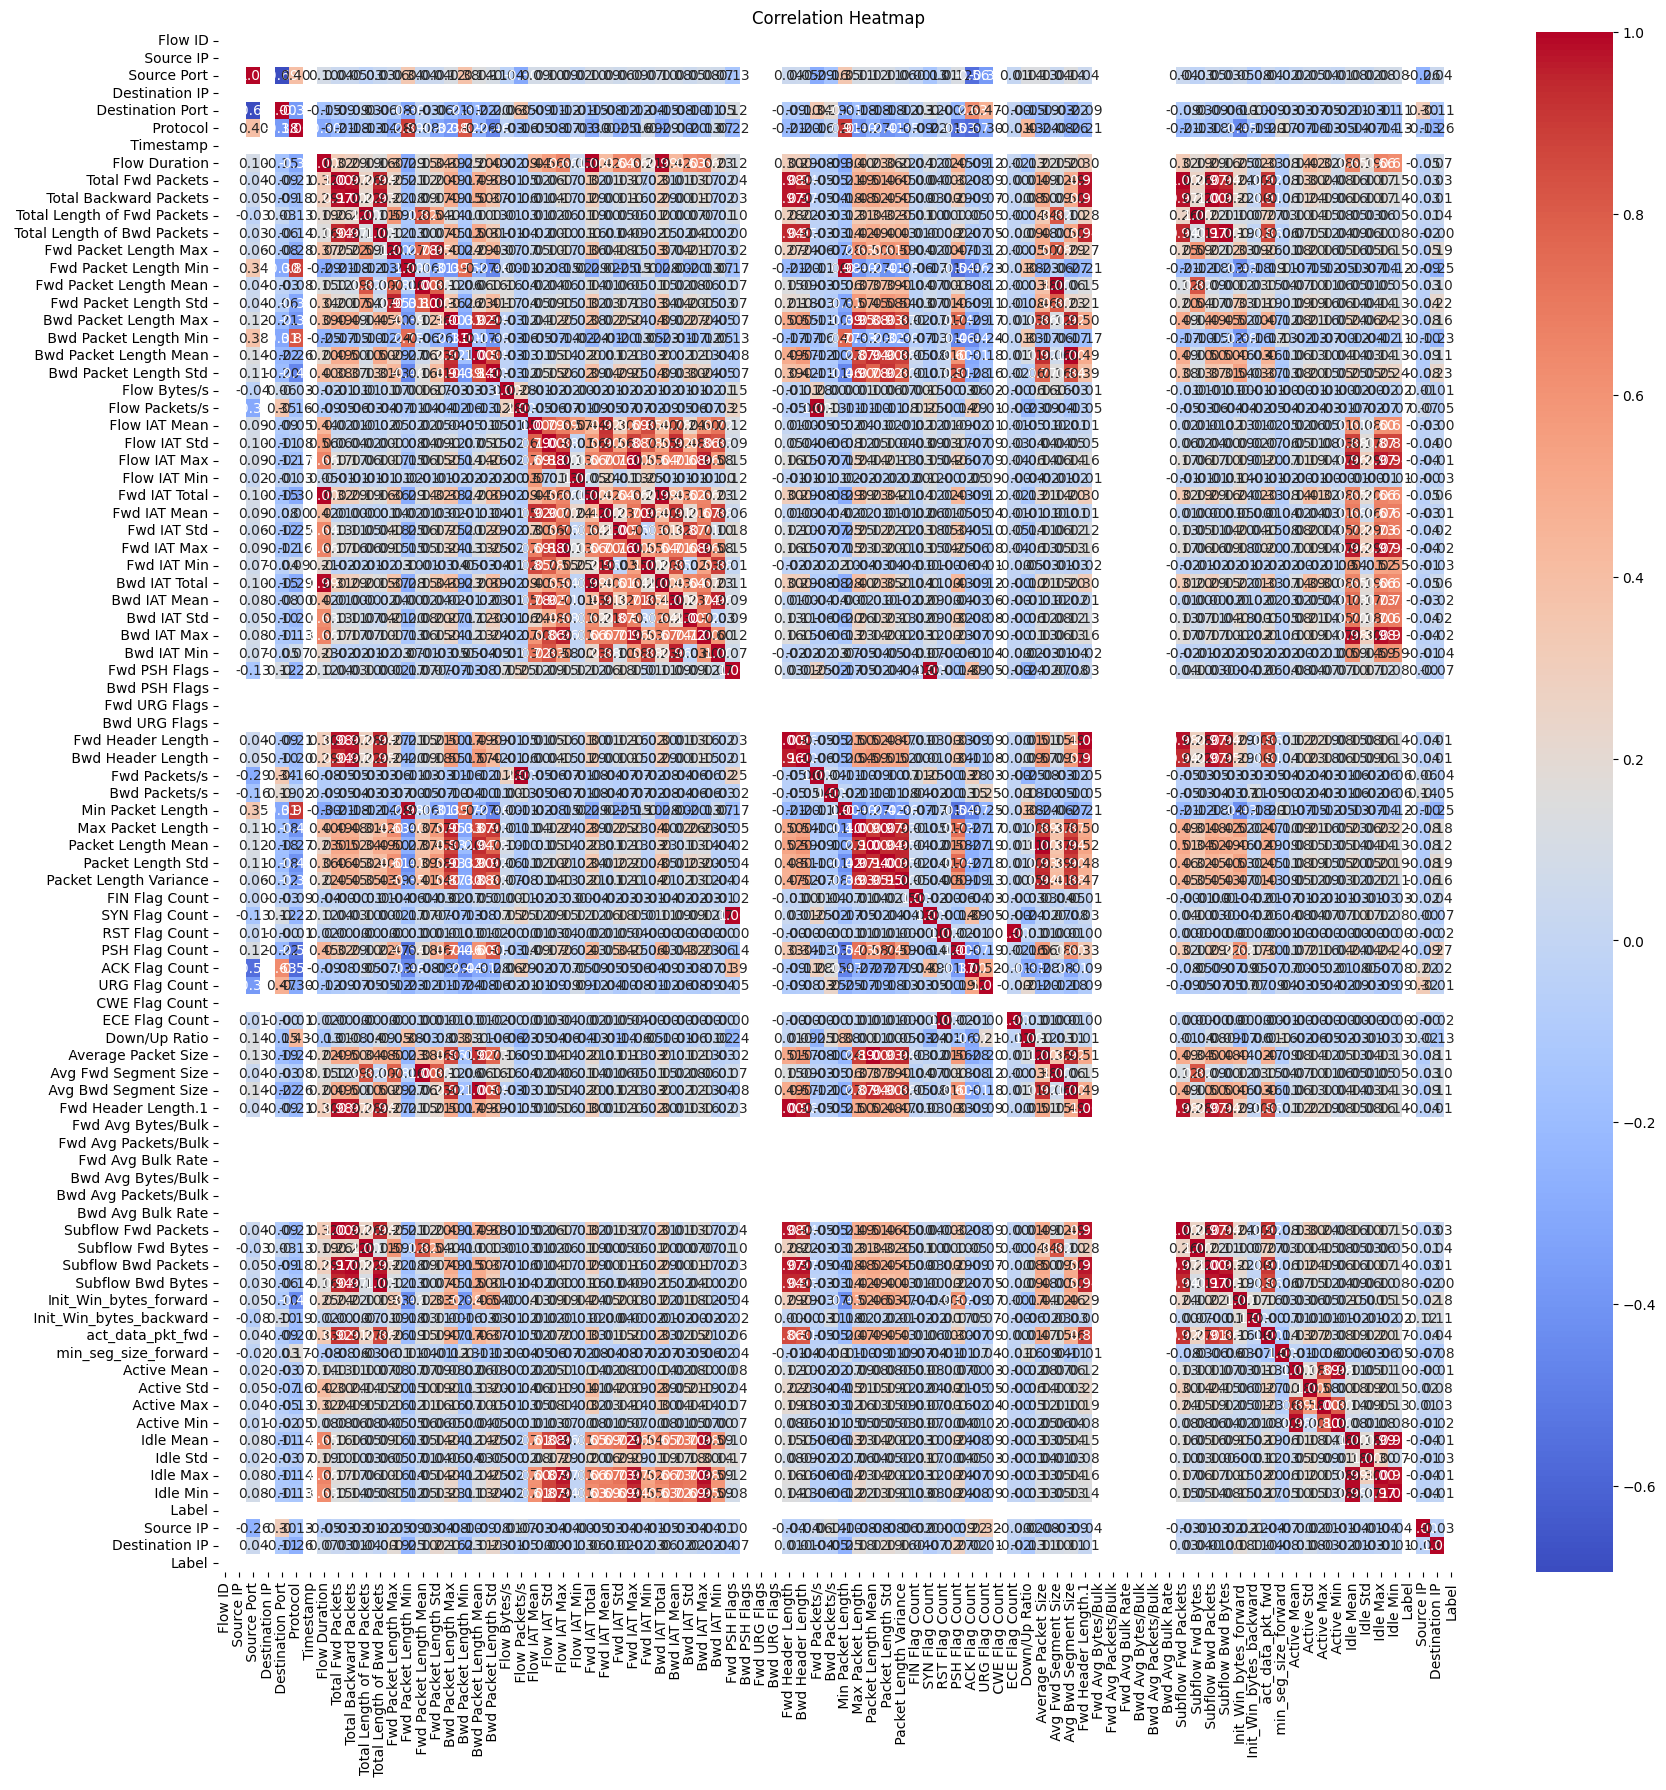

In [ ]:
# Convert all possible columns to numeric
df_numeric = df.apply(pd.to_numeric, errors='coerce')

# Compute correlation matrix
correlation_matrix = df_numeric.corr()

# Plot heatmap
plt.figure(figsize=(20, 20))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()
